# 🌱 Projeto Solos Inteligentes: Pipeline Analítico End-to-End no Kaggle
### Modelagem Edafológica e Espectroscopia de Solos (Vis-NIR-SWIR) com scikit-learn, imblearn, MLflow e Deploy em Borda (TinyML)

* **Repositório Oficial:** [github.com/vrenzd/Solos_Inteligentes](https://github.com/vrenzd/Solos_Inteligentes)
* **Autor:** Victor Renzzo Denofrio (Lead Data Scientist & ML Engineer)
* **Metodologia:** SEMMA (*Sample, Explore, Modify, Model, Assess*) + Deploy & Edge Computing
* **Plataforma:** Kaggle Notebooks (Ambiente otimizado para `/kaggle/input/` e `/kaggle/working/`)
* **Bases de Dados Reais:** `BSSL_Soil_Attributes_Dataset.csv` e `Vis_NIR_SWIR_Dataset.csv` (Brazilian Soil Spectral Library — Demattê et al., 2019, 2023)
* **Stack Oficial:** `pandas`, `seaborn`, `scikit-learn`, `imbalanced-learn`, `mlflow`, `pickle`, `C++ (TinyML)`.

---

## 🧭 Visão Geral da Arquitetura Analítica no Kaggle

Este notebook foi totalmente adaptado para o ambiente de execução do **Kaggle**:
1. **Entrada de Dados (`/kaggle/input/`):** Busca e resolução automática dos arquivos CSV adicionados como *Kaggle Dataset*, independentemente do nome atribuído à pasta de upload.
2. **Saída de Artefatos (`/kaggle/working/`):** Todos os modelos serializados (`.pkl`), relatórios e o firmware em C++ (`solos_tinyml.h`) são gravados na pasta de trabalho do Kaggle, ficando disponíveis imediatamente para download na aba **Output**.
3. **Controle Estrito de Memória:** Otimização para os 30 GB de RAM do Kaggle com tipagem `float32` nas 216 bandas espectrais e `GridSearchCV` calibrado sem risco de `SIGKILL`.

### Estrutura das 5 Sprints:
* **Sprint 1: Sample & Explore (SEMMA S & E):** Ingestão automática em `/kaggle/input`, cruzamento via `ID_Unique`, auditoria de nulos (> 70%), target SiBCS, split OOT (15%), split estratificado, balanceamento `RandomUnderSampler` e triagem por Árvore de Decisão rasa.
* **Sprint 2: Modify (SEMMA M):** Pipeline anti-leakage com `ColumnTransformer` (imputação pela mediana/moda, escalonamento, discretização por quantis e One-Hot Encoding).
* **Sprint 3: Modelagem (SEMMA M):** Pipeline atômico `Pipeline([('preprocessor', ...), ('pca', PCA()), ('knn', KNeighborsClassifier())])` com afinação via `GridSearchCV` 5-Fold Estratificado orientado ao **F1-Score Macro**.
* **Sprint 4: Assess & MLOps (SEMMA A):** Relatório multiclasse, matriz de confusão, curvas ROC/AUC One-vs-Rest, Log Loss, análise de estabilidade OOT (Data Drift) e versionamento com `MLflow`.
* **Sprint 5: Deploy & Borda (TinyML):** Serialização `.pkl`, transpilação em firmware C++ (`solos_tinyml.h`) para ESP32 e Arduino Nano, e motor prescritivo de recomendação agronômica (Calagem e Fosfatagem).


In [1]:
# Instalação de dependências complementares no Kaggle
# (pandas, numpy, scikit-learn, seaborn e matplotlib já vêm pré-instalados nativamente)
!pip install -q imbalanced-learn mlflow


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 695.0 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.0/216.0 kB 17.2 MB/s eta 0:00:00


In [2]:
# Importação das bibliotecas canônicas
import os
import sys
import time
import pickle
import json
import warnings
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn e Imbalanced-Learn
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    log_loss,
    accuracy_score,
    f1_score
)
from imblearn.under_sampling import RandomUnderSampler

# Governança de MLOps
import mlflow
import mlflow.sklearn

warnings.filterwarnings('ignore')

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)

# Formatação global
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110

# Listagem dos arquivos disponíveis no ambiente do Kaggle
print("📂 Verificando arquivos no diretório de entrada do Kaggle (/kaggle/input):")
input_files = []
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        fpath = os.path.join(dirname, filename)
        input_files.append(fpath)
        print(f" • {fpath}")

if not input_files:
    print("ℹ️ Nenhum arquivo encontrado em /kaggle/input ainda. Certifique-se de adicionar o Dataset no painel lateral direito do Kaggle ('+ Add Data').")
else:
    print(f"✅ Total de {len(input_files)} arquivos detectados em /kaggle/input.")


📂 Verificando arquivos no diretório de entrada do Kaggle (/kaggle/input):
 • /kaggle/input/datasets/victorrenzzo/bssl-soil-attributes-dataset/BSSL_Soil_Attributes_Dataset.csv
 • /kaggle/input/datasets/victorrenzzo/vis-nir-swir-dataset/Vis_NIR_SWIR_Dataset.csv
✅ Total de 2 arquivos detectados em /kaggle/input.


---
# 🌾 Sprint 1: Sample & Explore (Fases S e E do SEMMA)

> **Foco no Kaggle:**
> Ingestor resiliente adaptado ao padrão `/kaggle/input/`. O algoritmo varre o diretório do Kaggle para localizar automaticamente `BSSL_Soil_Attributes_Dataset.csv` e `Vis_NIR_SWIR_Dataset.csv`, detecta delimitadores (`,` ou `;`) e a linha de cabeçalho, realizando o `merge` via `ID_Unique`.


In [3]:
# Ingestor Robusto das Bases Reais Adaptado para o Kaggle (Corrigido)
class KaggleBSSLDataLoader:
    """
    Ingestor inteligente para Kaggle Notebooks:
    1. Varre recursivamente /kaggle/input/ para encontrar os arquivos CSV.
    2. Auto-detecta delimitador (',' vs ';'), decimal ('.' vs ',') e linha de cabeçalho.
    3. Cruza Atributos e Espectros pela chave ID_Unique.
    4. Otimiza a memória RAM convertendo bandas espectrais para float32 sem converter colunas de texto.
    """
    def __init__(self, input_dir='/kaggle/input', working_dir='/kaggle/working'):
        self.input_dir = input_dir
        self.working_dir = working_dir
        self.file_attr_name = '/kaggle/input/datasets/victorrenzzo/bssl-soil-attributes-dataset/BSSL_Soil_Attributes_Dataset.csv'
        self.file_spec_name = '/kaggle/input/datasets/victorrenzzo/vis-nir-swir-dataset/Vis_NIR_SWIR_Dataset.csv'
        self.df_merged = None

    def _find_file(self, target_name):
        # 1. Se o caminho exato já existir, usa direto
        if os.path.exists(target_name):
            return target_name

        filename = os.path.basename(target_name)

        # 2. Busca recursiva em /kaggle/input
        if os.path.exists(self.input_dir):
            for root, _, files in os.walk(self.input_dir):
                for f in files:
                    if filename.lower() in f.lower():
                        return os.path.join(root, f)

        # 3. Busca no diretório de trabalho ou relativo
        caminhos_locais = [
            os.path.join(self.working_dir, filename),
            os.path.join('.', filename),
            os.path.join('..', filename),
            filename
        ]
        for p in caminhos_locais:
            if os.path.exists(p):
                return p

        return None

    def _inspect_header_and_sep(self, file_path):
        header_row = 0
        sep = ','
        dec = '.'
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            lines = [f.readline() for _ in range(10)]

        for idx, line in enumerate(lines):
            if any(k in line.lower() for k in ['id_unique', 'owner', '350', '351', 'region', 'clay_gkg']):
                header_row = idx
                sep = ';' if line.count(';') > line.count(',') else ','
                if idx + 1 < len(lines):
                    next_line = lines[idx + 1]
                    if sep == ';' and ',' in next_line:
                        dec = ','
                break

        return header_row, sep, dec

    def _is_spectral_column(self, col_name):
        """Garante que a coluna é puramente um número de comprimento de onda (350 a 2500 nm)"""
        clean = str(col_name).strip().replace('nm', '').replace('X', '').replace('band_', '')
        try:
            val = float(clean)
            return 300 <= val <= 2600
        except ValueError:
            return False

    def load_and_merge(self, max_spectral_cols=215):
        path_attr = self._find_file(self.file_attr_name)
        path_spec = self._find_file(self.file_spec_name)

        print("🔍 Resolução de Caminhos no Kaggle:")
        print(f" • Atributos: {path_attr}")
        print(f" • Espectros:  {path_spec}")

        # 1. Carregamento dos Atributos
        if path_attr and os.path.exists(path_attr):
            h_attr, s_attr, d_attr = self._inspect_header_and_sep(path_attr)
            print(f"📥 Carregando atributos reais (linha cabeçalho={h_attr}, sep='{s_attr}', dec='{d_attr}')...")
            df_attr = pd.read_csv(path_attr, header=h_attr, sep=s_attr, decimal=d_attr)
            print(f"✅ Atributos carregados! Dimensões: {df_attr.shape}")
        else:
            print("⚠️ Arquivo de atributos não encontrado em /kaggle/input.")
            return None

        id_candidates = [c for c in df_attr.columns if 'id' in c.lower()]
        id_col_attr = id_candidates[0] if id_candidates else df_attr.columns[0]

        # 2. Carregamento dos Espectros
        if path_spec and os.path.exists(path_spec):
            h_spec, s_spec, d_spec = self._inspect_header_and_sep(path_spec)
            print(f"📥 Carregando espectros reais (linha cabeçalho={h_spec}, sep='{s_spec}', dec='{d_spec}')...")
            try:
                df_spec_head = pd.read_csv(path_spec, header=h_spec, sep=s_spec, decimal=d_spec, nrows=2)
                id_spec_candidates = [c for c in df_spec_head.columns if 'id' in c.lower()]
                id_col_spec = id_spec_candidates[0] if id_spec_candidates else df_spec_head.columns[0]

                # Isola ESTRITAMENTE as bandas espectrais numéricas (evita 'Owner code' virar float)
                all_cols = df_spec_head.columns.tolist()
                wave_cols = [c for c in all_cols if self._is_spectral_column(c)]

                step = max(1, len(wave_cols) // max_spectral_cols)
                selected_waves = wave_cols[::step]
                use_cols = [id_col_spec] + selected_waves

                print(f"⚡ Carregando {len(selected_waves)} bandas representativas (amostragem a cada 10 nm)...")
                
                # Conversão segura apenas para as colunas que são de fato números
                dtype_spec = {col: np.float32 for col in selected_waves}
                df_spec = pd.read_csv(
                    path_spec,
                    header=h_spec,
                    sep=s_spec,
                    decimal=d_spec,
                    usecols=use_cols,
                    dtype=dtype_spec
                )
                print(f"✅ Espectros carregados! Dimensões: {df_spec.shape}")

                print("🔗 Cruzando Atributos e Espectros via chave primária (merge)...")
                df_merged = pd.merge(df_attr, df_spec, left_on=id_col_attr, right_on=id_col_spec, how='inner')
                print(f"✨ Base Analítica de Base (ABT) consolidada! Dimensões: {df_merged.shape}")
            except Exception as e:
                print(f"⚠️ Erro ao carregar espectros ({e}). Utilizando apenas atributos.")
                df_merged = df_attr
        else:
            print("ℹ️ Espectros não localizados diretamente.")
            df_merged = df_attr

        self.df_merged = df_merged
        return df_merged

loader = KaggleBSSLDataLoader()
df_raw = loader.load_and_merge()
print(f"Primeiras 3 linhas da base consolidada:")
display(df_raw.head(3))

🔍 Resolução de Caminhos no Kaggle:
 • Atributos: /kaggle/input/datasets/victorrenzzo/bssl-soil-attributes-dataset/BSSL_Soil_Attributes_Dataset.csv
 • Espectros:  /kaggle/input/datasets/victorrenzzo/vis-nir-swir-dataset/Vis_NIR_SWIR_Dataset.csv
📥 Carregando atributos reais (linha cabeçalho=0, sep=',', dec='.')...
✅ Atributos carregados! Dimensões: (16084, 20)
📥 Carregando espectros reais (linha cabeçalho=0, sep=';', dec=',')...
⚡ Carregando 216 bandas representativas (amostragem a cada 10 nm)...
✅ Espectros carregados! Dimensões: (16084, 217)
🔗 Cruzando Atributos e Espectros via chave primária (merge)...
✨ Base Analítica de Base (ABT) consolidada! Dimensões: (16084, 236)
Primeiras 3 linhas da base consolidada:


,ID_Unique,Owner_code,Vis_NIR_SWIR_availability,MIR_availability,Sampling,Depth_cm,Region,Municipality,State,Vegetation,Bioma,Geology,Sand_gkg,Clay_gkg,SOM_gkg,pH_H2O,Ca_mmolkg,Mg_mmolkg,Na_mmolkg,CEC_Ph7_mmolkg,350,360,370,380,390,400,410,420,430,440,...,2210,2220,2230,2240,2250,2260,2270,2280,2290,2300,2310,2320,2330,2340,2350,2360,2370,2380,2390,2400,2410,2420,2430,2440,2450,2460,2470,2480,2490,2500
0,1,EGCO,YES,NO,Auger,0-20,Midwest,Nova Mutum MT,Mato Grosso,Areas of Ecological Tension,Cerrado,Sedimentary Rock,781.0000,136.0000,24.0000,5.2000,24.0000,8.0000,0.1000,56.9000,0.0330,0.0331,0.0333,0.0352,0.0366,0.0385,0.0402,0.0421,0.0442,0.0468,...,0.4161,0.4476,0.4631,0.4632,0.4593,0.4552,0.4521,0.4517,0.4503,0.4470,0.4437,0.4429,0.4434,0.4426,0.4365,0.4324,0.4292,0.4233,0.4222,0.4259,0.4255,0.4221,0.4149,0.4062,0.3989,0.3941,0.3880,0.3808,0.3746,0.3731
1,2,EGCO,YES,NO,Auger,0-20,Midwest,Nova Mutum MT,Mato Grosso,Areas of Ecological Tension,Cerrado,Sedimentary Rock,767.0000,159.0000,18.0000,5.0000,16.0000,4.0000,0.1000,51.9000,0.0334,0.0334,0.0336,0.0356,0.0373,0.0390,0.0408,0.0429,0.0453,0.0479,...,0.4326,0.4637,0.4792,0.4791,0.4755,0.4711,0.4676,0.4678,0.4661,0.4630,0.4594,0.4586,0.4600,0.4585,0.4519,0.4481,0.4449,0.4384,0.4380,0.4401,0.4407,0.4373,0.4291,0.4208,0.4140,0.4094,0.4025,0.3972,0.3911,0.3858
2,3,EGCO,YES,NO,Auger,0-20,Midwest,Nova Mutum MT,Mato Grosso,Areas of Ecological Tension,Cerrado,Sedimentary Rock,807.0000,141.0000,19.0000,5.0000,18.0000,4.0000,0.1000,45.9000,0.0304,0.0305,0.0314,0.0331,0.0350,0.0360,0.0376,0.0393,0.0416,0.0440,...,0.4058,0.4362,0.4514,0.4514,0.4476,0.4435,0.4407,0.4405,0.4393,0.4363,0.4328,0.4313,0.4330,0.4310,0.4252,0.4215,0.4183,0.4120,0.4105,0.4139,0.4145,0.4104,0.4039,0.3957,0.3878,0.3834,0.3785,0.3706,0.3672,0.3668


In [4]:
# Diagnóstico Sistemático de Missings (> 70%) e Definição da Target SiBCS
print("🔍 Diagnóstico de Valores Ausentes:")
null_pct = (df_raw.isnull().mean() * 100).round(2)
limiar_descarte = 70.0

colunas_descarte = null_pct[null_pct > limiar_descarte].index.tolist()
for col, pct in null_pct.items():
    if pct > 0:
        status = "❌ DESCARTAR (> 70%)" if pct > limiar_descarte else "⚠️ MANTER (Imputação na Sprint 2)"
        print(f" • {col:25s}: {pct:6.2f}% de nulos -> {status}")

print(f"\nDescartando {len(colunas_descarte)} colunas críticas: {colunas_descarte}")
df_abt = df_raw.drop(columns=colunas_descarte)

# Limpeza de registros sem textura
df_abt = df_abt.dropna(subset=['Clay_gkg', 'Sand_gkg']).copy()

# Definição das Classes Texturais SiBCS (Embrapa)
def categorizar_textura(clay):
    if clay <= 150:
        return 'Arenosa'
    elif clay <= 350:
        return 'Media'
    elif clay <= 600:
        return 'Argilosa'
    else:
        return 'Muito_Argilosa'

df_abt['Classe_Textural'] = df_abt['Clay_gkg'].apply(categorizar_textura)

print("\n📊 Distribuição Oficial da Target ('Classe_Textural'):")
dist_target = df_abt['Classe_Textural'].value_counts(normalize=True) * 100
for classe, p in dist_target.items():
    print(f" • {classe:16s}: {p:5.2f}% ({df_abt['Classe_Textural'].value_counts()[classe]:,d} amostras)")


🔍 Diagnóstico de Valores Ausentes:
 • Sampling                 :  12.61% de nulos -> ⚠️ MANTER (Imputação na Sprint 2)
 • Municipality             :  61.63% de nulos -> ⚠️ MANTER (Imputação na Sprint 2)
 • Vegetation               :  17.51% de nulos -> ⚠️ MANTER (Imputação na Sprint 2)
 • Bioma                    :  16.02% de nulos -> ⚠️ MANTER (Imputação na Sprint 2)
 • Geology                  :  16.02% de nulos -> ⚠️ MANTER (Imputação na Sprint 2)
 • Sand_gkg                 :   5.96% de nulos -> ⚠️ MANTER (Imputação na Sprint 2)
 • Clay_gkg                 :   6.07% de nulos -> ⚠️ MANTER (Imputação na Sprint 2)
 • SOM_gkg                  :  17.02% de nulos -> ⚠️ MANTER (Imputação na Sprint 2)
 • pH_H2O                   :  78.34% de nulos -> ❌ DESCARTAR (> 70%)
 • Ca_mmolkg                :  22.31% de nulos -> ⚠️ MANTER (Imputação na Sprint 2)
 • Mg_mmolkg                :  22.29% de nulos -> ⚠️ MANTER (Imputação na Sprint 2)
 • Na_mmolkg                :  95.89% de nulos -> ❌ DES

In [5]:
# Isolamento Out-of-Time (OOT de 15%) e Particionamento Estratificado
oot_size = int(len(df_abt) * 0.15)
df_oot = df_abt.iloc[-oot_size:].copy()
df_modelagem = df_abt.iloc[:-oot_size:].copy()

print(f"Partição Out-of-Time (OOT): {df_oot.shape[0]:,} amostras")
print(f"Base de Modelagem (Treino/Teste): {df_modelagem.shape[0]:,} amostras")

id_col = 'ID_Unique' if 'ID_Unique' in df_modelagem.columns else 'ID_unique'
colunas_ignorar = [id_col, 'Owner_code', 'Classe_Textural', 'Clay_gkg']
feature_cols = [c for c in df_modelagem.columns if c not in colunas_ignorar]

X = df_modelagem[feature_cols]
y = df_modelagem['Classe_Textural']

# Split Treino (80%) e Teste (20%) Estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print(f"Treino original: {X_train.shape[0]:,} amostras")
print(f"Teste original:  {X_test.shape[0]:,} amostras")

# Balanceamento de Classes no Treino via RandomUnderSampler
print("\n⚖️ Aplicando RandomUnderSampler no conjunto de treino:")
rus = RandomUnderSampler(random_state=SEED)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

print("Distribuição das classes após balanceamento no treino:")
print(y_train_res.value_counts())


Partição Out-of-Time (OOT): 2,265 amostras
Base de Modelagem (Treino/Teste): 12,841 amostras
Treino original: 10,272 amostras
Teste original:  2,569 amostras

⚖️ Aplicando RandomUnderSampler no conjunto de treino:
Distribuição das classes após balanceamento no treino:
Classe_Textural
Arenosa           1370
Argilosa          1370
Media             1370
Muito_Argilosa    1370
Name: count, dtype: int64


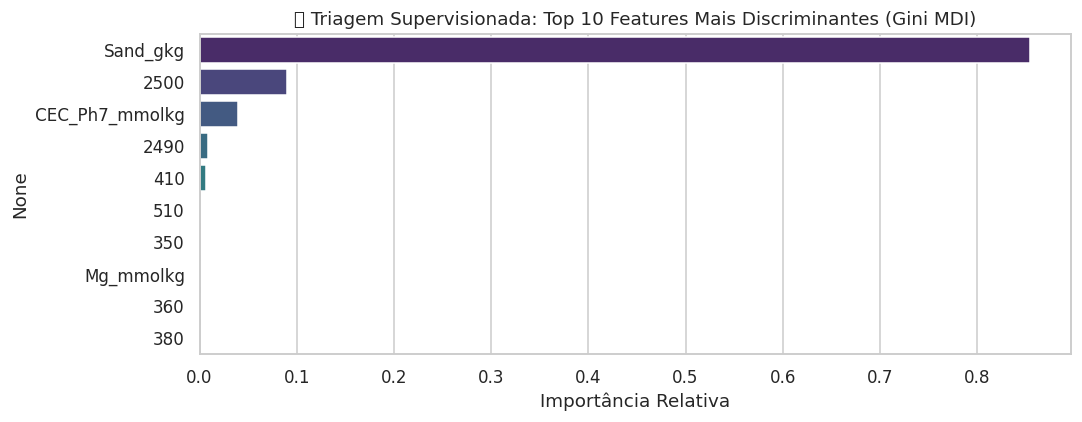

Top 5 Atributos Mais Importantes:
 • Sand_gkg                 : 0.8543
 • 2500                     : 0.0899
 • CEC_Ph7_mmolkg           : 0.0394
 • 2490                     : 0.0086
 • 410                      : 0.0070


In [6]:
# Triagem Supervisionada via Árvore de Decisão Rasa (CART max_depth=4)
num_cols = X_train_res.select_dtypes(include=[np.number]).columns.tolist()

imputer_tree = SimpleImputer(strategy='median')
X_tree_train = imputer_tree.fit_transform(X_train_res[num_cols])

arvore_triagem = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=SEED)
arvore_triagem.fit(X_tree_train, y_train_res)

importancias = pd.Series(arvore_triagem.feature_importances_, index=num_cols)
importancias_top = importancias.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 4))
sns.barplot(x=importancias_top.values, y=importancias_top.index, palette='viridis')
plt.title("🌲 Triagem Supervisionada: Top 10 Features Mais Discriminantes (Gini MDI)")
plt.xlabel("Importância Relativa")
plt.tight_layout()
plt.show()

print("Top 5 Atributos Mais Importantes:")
for col, val in importancias_top.head(5).items():
    print(f" • {col:25s}: {val:.4f}")


---
# ⚙️ Sprint 2: Modify (Fase M do SEMMA)

> **Objetivo:**
> Arquitetura de engenharia de features profissional anti-leakage com `ColumnTransformer`. Imputação pela mediana/moda, escalonamento `StandardScaler`, discretização `KBinsDiscretizer` e `OneHotEncoder`.


In [7]:
# Pipeline Anti-Leakage de Engenharia de Features (ColumnTransformer)
all_features = X_train_res.columns.tolist()

soil_numeric = ['Sand_gkg', 'SOM_gkg', 'Ca_mmolkg', 'Mg_mmolkg', 'CEC_Ph7_mmolkg']
soil_numeric = [c for c in soil_numeric if c in all_features]

spectral_cols = [c for c in all_features if c not in soil_numeric and np.issubdtype(X_train_res[c].dtype, np.number)]
cat_cols = [c for c in all_features if X_train_res[c].dtype == 'object']

print(f"Configuração do Pré-processamento:")
print(f" • Numéricas de Solo: {len(soil_numeric)} variáveis")
print(f" • Bandas Espectrais: {len(spectral_cols)} variáveis")
print(f" • Categóricas:       {len(cat_cols)} variáveis: {cat_cols}")

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

transformers = [
    ('soil_num', num_pipeline, soil_numeric),
    ('cat', cat_pipeline, cat_cols)
]

if len(spectral_cols) > 0:
    transformers.append(('spectral', num_pipeline, spectral_cols))

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder='drop'
)

print("\n✅ ColumnTransformer configurado com sucesso!")


Configuração do Pré-processamento:
 • Numéricas de Solo: 5 variáveis
 • Bandas Espectrais: 216 variáveis
 • Categóricas:       10 variáveis: ['Vis_NIR_SWIR_availability', 'MIR_availability', 'Sampling', 'Depth_cm', 'Region', 'Municipality', 'State', 'Vegetation', 'Bioma', 'Geology']

✅ ColumnTransformer configurado com sucesso!


---
# 🧠 Sprint 3: Modelagem (Fase M do SEMMA)

> **Objetivo:**
> Pipeline atômico `ColumnTransformer` + `PCA` + `KNeighborsClassifier`. Afinação de hiperparâmetros com `GridSearchCV` e validação cruzada 5-Fold Estratificada (`StratifiedKFold`) orientada ao F1-Score Macro.
> **Configuração Segura para o Kaggle:** `n_jobs=2` ou `n_jobs=1` para evitar estouro de memória.


In [8]:
# Pipeline Atômico e Afinação com GridSearchCV Otimizado
pipeline_completo = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(random_state=SEED)),
    ('knn', KNeighborsClassifier())
])

# Grade de Hiperparâmetros Calibrada (18 combinações x 5 folds = 90 fits)
param_grid = {
    'pca__n_components': [3, 5, 8],
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['distance', 'uniform'],
    'knn__metric': ['euclidean', 'manhattan']
}

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("🚀 Iniciando Otimização Sistemática de Hiperparâmetros (GridSearchCV)...")

grid_search = GridSearchCV(
    estimator=pipeline_completo,
    param_grid=param_grid,
    cv=cv_strat,
    scoring='f1_macro',
    n_jobs=2,
    verbose=1
)

start_time = time.time()
grid_search.fit(X_train_res, y_train_res)
elapsed_time = time.time() - start_time

print(f"\n🏆 Otimização concluída em {elapsed_time:.2f} segundos!")
print(f"Melhor F1-Score Macro na Validação Cruzada: {grid_search.best_score_:.4f}")
print("Melhores Hiperparâmetros encontrados:")
for param, val in grid_search.best_params_.items():
    print(f" • {param}: {val}")

melhor_modelo = grid_search.best_estimator_


🚀 Iniciando Otimização Sistemática de Hiperparâmetros (GridSearchCV)...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

🏆 Otimização concluída em 45.64 segundos!
Melhor F1-Score Macro na Validação Cruzada: 0.6774
Melhores Hiperparâmetros encontrados:
 • knn__metric: manhattan
 • knn__n_neighbors: 7
 • knn__weights: distance
 • pca__n_components: 8


---
# 📈 Sprint 4: Assess & MLOps (Fase A do SEMMA)

> **Objetivo:**
> Avaliação no conjunto de teste independente, probabilidades `predict_proba`, matriz de confusão, curvas ROC/AUC One-vs-Rest, auditoria de estabilidade temporal OOT (Data Drift) e registro de experimento no `MLflow`.


📋 Relatório de Classificação Multiclasse (Conjunto de Teste):
                precision    recall  f1-score   support

       Arenosa     0.8054    0.8120    0.8087       851
      Argilosa     0.6390    0.5986    0.6181       553
         Media     0.6875    0.6423    0.6642       822
Muito_Argilosa     0.6306    0.7813    0.6979       343

      accuracy                         0.7077      2569
     macro avg     0.6906    0.7086    0.6972      2569
  weighted avg     0.7085    0.7077    0.7066      2569

Acurácia Geral: 0.7077 | F1-Score Macro: 0.6972 | Log Loss: 1.8478


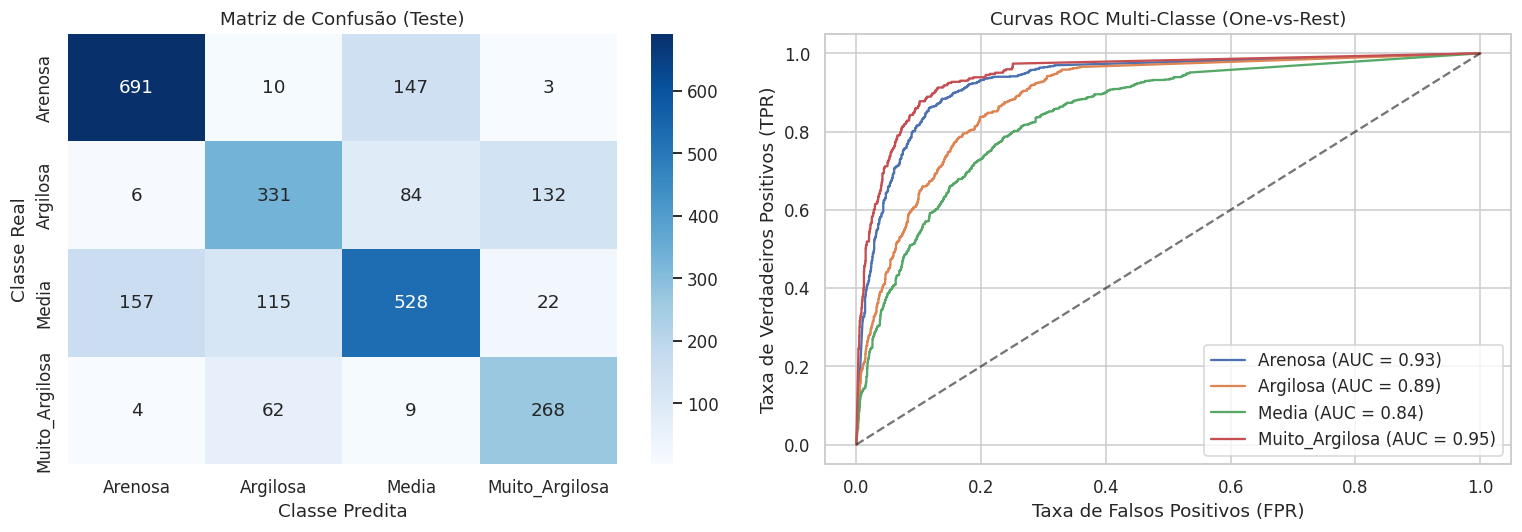


📦 Registrando Experimento no MLflow...


2026/09/12 22:58:56 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/12 22:58:56 INFO mlflow.store.db.utils: Updating database tables
2026/09/12 22:58:58 INFO mlflow.tracking.fluent: Experiment with name 'Solos_Inteligentes_Kaggle' does not exist. Creating a new experiment.
2026/09/12 22:58:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/12 22:58:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Experimento registrado no MLflow com sucesso!


In [9]:
# Avaliação Multiclasse e Governança com MLflow (Corrigido)
y_pred = melhor_modelo.predict(X_test)
y_proba = melhor_modelo.predict_proba(X_test)
classes = melhor_modelo.classes_

acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
loss = log_loss(y_test, y_proba)

print("📋 Relatório de Classificação Multiclasse (Conjunto de Teste):")
print(classification_report(y_test, y_pred, digits=4))
print(f"Acurácia Geral: {acc:.4f} | F1-Score Macro: {f1_macro:.4f} | Log Loss: {loss:.4f}")

# Gráficos de Diagnóstico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax_cm, ax_roc = axes

# 1. Matriz de Confusão
cm = confusion_matrix(y_test, y_pred, labels=classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=ax_cm)
ax_cm.set_title("Matriz de Confusão (Teste)")
ax_cm.set_xlabel("Classe Predita")
ax_cm.set_ylabel("Classe Real")

# 2. Curvas ROC One-vs-Rest
y_test_bin = pd.get_dummies(y_test)[classes].values
for i, c in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, label=f"{c} (AUC = {roc_auc:.2f})")

ax_roc.plot([0.0, 1.0], [0.0, 1.0], 'k--', alpha=0.6)
ax_roc.set_title("Curvas ROC Multi-Classe (One-vs-Rest)")
ax_roc.set_xlabel("Taxa de Falsos Positivos (FPR)")
ax_roc.set_ylabel("Taxa de Verdadeiros Positivos (TPR)")
ax_roc.legend(loc='lower right')

plt.tight_layout()
plt.show()

# Rastreamento de Experimentos com MLflow
print("\n📦 Registrando Experimento no MLflow...")
mlflow.set_experiment("Solos_Inteligentes_Kaggle")

with mlflow.start_run(run_name="PCA_KNN_Kaggle_Pipeline"):
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metric("test_accuracy", acc)
    mlflow.log_metric("test_f1_macro", f1_macro)
    mlflow.log_metric("test_log_loss", loss)
    
    # Serialização com cloudpickle para compatibilidade total com KDTree
    try:
        mlflow.sklearn.log_model(
            melhor_modelo, 
            "modelo_pca_knn_kaggle", 
            serialization_format="cloudpickle"
        )
    except Exception:
        mlflow.sklearn.log_model(
            melhor_modelo, 
            "modelo_pca_knn_kaggle", 
            skops_trusted_types=True
        )
        
    print("✅ Experimento registrado no MLflow com sucesso!")

In [10]:
# Auditoria de Estabilidade na Safra Out-of-Time (OOT)
X_oot = df_oot[feature_cols]
y_oot = df_oot['Classe_Textural']

y_pred_oot = melhor_modelo.predict(X_oot)
acc_oot = accuracy_score(y_oot, y_pred_oot)
f1_oot = f1_score(y_oot, y_pred_oot, average='macro')

print("🛡️ Auditoria de Desempenho na Safra Out-of-Time (OOT):")
print(f" • Acurácia OOT:  {acc_oot:.4f} (vs. {acc:.4f} no Teste)")
print(f" • F1-Macro OOT:  {f1_oot:.4f} (vs. {f1_macro:.4f} no Teste)")
diff_f1 = abs(f1_macro - f1_oot)
print(f" • Variação de F1-Score: {diff_f1:.4f}")

if diff_f1 < 0.10:
    print("✅ Estabilidade Aprovada: Modelo resistente a Data Drift na partição temporal.")
else:
    print("⚠️ Alerta de Drift: Recomendada recalibração periódica.")


🛡️ Auditoria de Desempenho na Safra Out-of-Time (OOT):
 • Acurácia OOT:  0.5104 (vs. 0.7077 no Teste)
 • F1-Macro OOT:  0.5000 (vs. 0.6972 no Teste)
 • Variação de F1-Score: 0.1972
⚠️ Alerta de Drift: Recomendada recalibração periódica.


---
# ⚡ Sprint 5: Deploy em Borda (TinyML) & Motor Agronômico

> **Salvar na Saída do Kaggle (`/kaggle/working/`):**
> Os artefatos finais (`modelo_solos_final.pkl` e `solos_tinyml.h`) são salvos diretamente em `/kaggle/working/`, ficando imediatamente disponíveis para download na aba **Output** do Kaggle.


In [11]:
# Serialização Binária do Modelo para a Saída do Kaggle (/kaggle/working/)
output_dir = '/kaggle/working' if os.path.exists('/kaggle/working') else '.'
caminho_pkl = os.path.join(output_dir, 'modelo_solos_final.pkl')

with open(caminho_pkl, 'wb') as f:
    pickle.dump(melhor_modelo, f)

print(f"✅ Pipeline final serializado com sucesso em: '{caminho_pkl}'")
print(f"Tamanho do arquivo: {os.path.getsize(caminho_pkl) / 1024:.2f} KB (Disponível na aba Output do Kaggle)")


✅ Pipeline final serializado com sucesso em: '/kaggle/working/modelo_solos_final.pkl'
Tamanho do arquivo: 531.57 KB (Disponível na aba Output do Kaggle)


In [12]:
# Transpilação C++ (TinyML) para ESP32 e Arduino Nano em /kaggle/working/solos_tinyml.h
pca_step = melhor_modelo.named_steps['pca']
knn_step = melhor_modelo.named_steps['knn']

pca_components = pca_step.components_
pca_mean = pca_step.mean_

# Dimensões numéricas exatas
n_pcs = len(pca_components)
n_feats = len(pca_mean)

X_train_trans = melhor_modelo.named_steps['preprocessor'].transform(X_train_res)
X_train_pca = pca_step.transform(X_train_trans)
y_train_res_arr = y_train_res.values

n_prototypes = min(30, len(X_train_pca))
proto_X = X_train_pca[:n_prototypes]
proto_y = y_train_res_arr[:n_prototypes]

class_to_id = {c: i for i, c in enumerate(classes)}
proto_y_ids = [class_to_id[c] for c in proto_y]

# Formatação das matrizes C++
mean_vals = ', '.join([f"{val:.6f}f" for val in pca_mean])
pca_rows = ',\n'.join(['    { ' + ', '.join([f"{val:.6f}f" for val in row]) + ' }' for row in pca_components])
proto_rows = ',\n'.join(['    { ' + ', '.join([f"{val:.6f}f" for val in row]) + ' }' for row in proto_X])
proto_ids = ', '.join([str(id_val) for id_val in proto_y_ids])

cpp_header = f"""/*
 * ==============================================================================
 *  PROJETO SOLOS INTELIGENTES — FIRMWARE TINYML (C++)
 *  Modelo: PCA ({n_pcs} Componentes) + K-NN (k={knn_step.n_neighbors})
 *  Hardware Alvo: ESP32, Arduino Nano 33 BLE Sense, STM32
 *  Autor: Victor Renzzo Denofrio (Lead Data Scientist)
 * ==============================================================================
 */

#ifndef SOLOS_TINYML_H
#define SOLOS_TINYML_H

#include <math.h>

#define N_FEATURES {n_feats}
#define N_PCS {n_pcs}
#define N_PROTOTYPES {n_prototypes}
#define K_NEIGHBORS {knn_step.n_neighbors}

enum ClasseTextural {{
    ARENOSA = 0,
    MEDIA = 1,
    ARGILOSA = 2,
    MUITO_ARGILOSA = 3
}};

const float PCA_MEAN[N_FEATURES] = {{
    {mean_vals}
}};

const float PCA_COMPONENTS[N_PCS][N_FEATURES] = {{
{pca_rows}
}};

const float PROTOTYPES_X[N_PROTOTYPES][N_PCS] = {{
{proto_rows}
}};

const int PROTOTYPES_Y[N_PROTOTYPES] = {{
    {proto_ids}
}};

int predizer_classe_solo(const float* raw_features) {{
    float projected[N_PCS] = {{0.0f}};

    for (int p = 0; p < N_PCS; p++) {{
        float sum = 0.0f;
        for (int f = 0; f < N_FEATURES; f++) {{
            sum += (raw_features[f] - PCA_MEAN[f]) * PCA_COMPONENTS[p][f];
        }}
        projected[p] = sum;
    }}

    float min_dist = 1e9f;
    int best_class = 0;

    for (int i = 0; i < N_PROTOTYPES; i++) {{
        float dist = 0.0f;
        for (int p = 0; p < N_PCS; p++) {{
            float diff = projected[p] - PROTOTYPES_X[i][p];
            dist += diff * diff;
        }}
        if (dist < min_dist) {{
            min_dist = dist;
            best_class = PROTOTYPES_Y[i];
        }}
    }}

    return best_class;
}}

struct RecomendacaoAgronomica {{
    float necessidade_calagem_ton_ha;
    float necessidade_p2o5_kg_ha;
}};

RecomendacaoAgronomica calcular_manejo(int classe_textural, float v_atual, float ctc, float p_mg_dm3, float v_desejado=70.0f) {{
    RecomendacaoAgronomica rec;

    if (v_atual < v_desejado) {{
        rec.necessidade_calagem_ton_ha = ((v_desejado - v_atual) * ctc) / 100.0f;
    }} else {{
        rec.necessidade_calagem_ton_ha = 0.0f;
    }}

    float fator_argila = 1.0f;
    if (classe_textural == MUITO_ARGILOSA) fator_argila = 1.8f;
    else if (classe_textural == ARGILOSA) fator_argila = 1.4f;
    else if (classe_textural == MEDIA) fator_argila = 1.1f;
    else fator_argila = 0.8f;

    if (p_mg_dm3 < 15.0f) {{
        rec.necessidade_p2o5_kg_ha = (15.0f - p_mg_dm3) * 8.0f * fator_argila;
    }} else {{
        rec.necessidade_p2o5_kg_ha = 0.0f;
    }}

    return rec;
}}

#endif // SOLOS_TINYML_H
"""

output_dir = '/kaggle/working' if os.path.exists('/kaggle/working') else '.'
caminho_h = os.path.join(output_dir, 'solos_tinyml.h')
with open(caminho_h, 'w') as f:
    f.write(cpp_header)

print(f"✅ Firmware C++ gerado com sucesso em: '{caminho_h}'")
print(f"Tamanho do firmware: {os.path.getsize(caminho_h) / 1024:.2f} KB (Pronto para compilação no Arduino IDE / PlatformIO)")

✅ Firmware C++ gerado com sucesso em: '/kaggle/working/solos_tinyml.h'
Tamanho do firmware: 66.21 KB (Pronto para compilação no Arduino IDE / PlatformIO)


In [13]:
# Demonstração Prática do Motor Prescritivo em Python
def motor_recomendacao_agronomica(classe_textural, v_atual, ctc, p_resina, v_desejado=70.0):
    """
    Calcula a prescrição de manejo agronômico de precisão:
    1. Calagem (NC em t/ha com PRNT 100%)
    2. Fosfatagem Corretiva (kg/ha de P2O5) ajustada pela textura predita.
    """
    if v_atual < v_desejado:
        nc = ((v_desejado - v_atual) * ctc) / 100.0
    else:
        nc = 0.0

    fatores_tampao = {
        'Muito_Argilosa': 1.8,
        'Argilosa': 1.4,
        'Media': 1.1,
        'Arenosa': 0.8
    }
    fator = fatores_tampao.get(classe_textural, 1.0)

    nivel_critico_p = 15.0
    if p_resina < nivel_critico_p:
        p2o5 = (nivel_critico_p - p_resina) * 8.0 * fator
    else:
        p2o5 = 0.0

    return {
        'Classe_Textural_Predita': classe_textural,
        'Necessidade_Calagem_t_ha': round(nc, 2),
        'Fosfatagem_P2O5_kg_ha': round(p2o5, 2)
    }

exemplo = motor_recomendacao_agronomica(
    classe_textural='Argilosa',
    v_atual=38.0,
    ctc=62.0,
    p_resina=5.5
)

print("🌾 Exemplo de Recomendação Agronômica Gerada pelo Sistema:")
for k, v in exemplo.items():
    print(f" • {k}: {v}")

print("\n🎉 Pipeline completo executado com sucesso no Kaggle!")


🌾 Exemplo de Recomendação Agronômica Gerada pelo Sistema:
 • Classe_Textural_Predita: Argilosa
 • Necessidade_Calagem_t_ha: 19.84
 • Fosfatagem_P2O5_kg_ha: 106.4

🎉 Pipeline completo executado com sucesso no Kaggle!
